# S&P 500 Decision Tree Analysis


In [1]:
# --- Import Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
from google.colab import files
uploaded = files.upload()


Saving sp500_2025_h1_wide_clean.csv to sp500_2025_h1_wide_clean.csv


In [4]:
# --- Load Dataset ---
df = pd.read_csv('sp500_2025_h1_wide_clean.csv')
df.head()

,company_name,ticker,02-01-2025_opening,02-01-2025_closing,02-01-2025_volume,03-01-2025_opening,03-01-2025_closing,03-01-2025_volume,06-01-2025_opening,06-01-2025_closing,...,25-06-2025_volume,26-06-2025_opening,26-06-2025_closing,26-06-2025_volume,27-06-2025_opening,27-06-2025_closing,27-06-2025_volume,30-06-2025_opening,30-06-2025_closing,30-06-2025_volume
0,Nvidia,NVDA,136.000,138.310,198247166,140.010,144.470,229322478,148.590,149.430,...,269146471,155.975,155.02,198145746,156.040,157.75,263234539,158.40,157.99,194580316
1,Microsoft,MSFT,425.530,418.580,16896469,421.080,423.350,16662943,428.000,427.850,...,17495099,492.980,497.45,21578853,497.550,495.94,34539236,497.04,497.41,28368991
2,Apple Inc.,AAPL,248.657,243.582,55802016,243.093,243.093,40288361,244.042,244.731,...,39525730,201.430,201.00,50799121,201.890,201.08,73188571,202.01,205.17,91912816
3,Amazon,AMZN,222.030,220.220,33956579,222.505,224.190,27515606,226.780,227.610,...,31755698,213.120,217.12,50480814,219.920,223.30,119217138,223.52,219.39,58887780
4,Meta Platforms,META,589.720,599.240,12682269,604.760,604.630,11436784,611.825,630.200,...,9320436,714.355,726.09,13964793,726.515,733.63,18775735,744.55,738.09,15402105


In [5]:
# --- Summary Statistics ---
df.describe()

,02-01-2025_opening,02-01-2025_closing,02-01-2025_volume,03-01-2025_opening,03-01-2025_closing,03-01-2025_volume,06-01-2025_opening,06-01-2025_closing,06-01-2025_volume,07-01-2025_opening,...,25-06-2025_volume,26-06-2025_opening,26-06-2025_closing,26-06-2025_volume,27-06-2025_opening,27-06-2025_closing,27-06-2025_volume,30-06-2025_opening,30-06-2025_closing,30-06-2025_volume
count,503.000000,503.000000,5.030000e+02,503.000000,503.000000,5.030000e+02,503.000000,503.000000,5.030000e+02,503.000000,...,5.030000e+02,503.000000,503.000000,5.030000e+02,503.000000,503.000000,5.030000e+02,503.000000,503.000000,5.030000e+02
mean,217.431673,215.383907,4.535764e+06,216.253498,217.523056,4.467972e+06,218.258478,217.394651,5.699455e+06,218.017770,...,5.847507e+06,221.366198,222.122246,6.118534e+06,222.517049,223.599237,9.353137e+06,224.032071,225.223419,6.806195e+06
std,480.924899,473.348505,1.222235e+07,474.494413,476.399099,1.284490e+07,477.305695,474.101269,1.532948e+07,476.154088,...,1.589694e+07,469.270678,472.115902,1.364678e+07,473.224870,478.852059,2.155338e+07,479.615982,483.450137,1.494309e+07
min,9.410000,9.350000,2.757100e+04,9.340000,9.330000,1.804400e+04,9.580000,9.430000,4.714400e+04,9.510000,...,1.934300e+04,8.970000,9.120000,2.461700e+04,9.120000,9.010000,2.751800e+04,9.040000,8.930000,2.116300e+04
25%,69.840000,69.270000,9.111230e+05,69.577500,69.865000,8.858790e+05,70.630000,71.090000,1.113781e+06,71.120000,...,1.191480e+06,68.587500,69.055000,1.228765e+06,69.450000,68.945000,1.959109e+06,68.757500,69.330000,1.384224e+06
50%,120.500000,120.630000,1.844594e+06,121.210000,121.580000,1.889257e+06,121.810000,121.000000,2.262657e+06,121.041200,...,2.467383e+06,127.580000,126.620000,2.575085e+06,126.880000,126.080000,3.796506e+06,126.295000,126.870000,2.769728e+06
75%,228.865000,228.335000,3.717299e+06,228.699350,229.215000,4.011698e+06,229.180000,229.400000,4.980843e+06,229.980000,...,5.085005e+06,238.487500,239.485000,5.690320e+06,239.092500,240.445000,8.287934e+06,240.682500,242.940000,5.869928e+06
max,8178.846000,7989.890000,1.982472e+08,8004.990000,8070.600000,2.293225e+08,8071.010000,7988.670000,2.653774e+08,8059.950000,...,2.691465e+08,7242.720000,7280.440000,1.981457e+08,7290.093000,7375.510000,2.632345e+08,7391.390000,7385.660000,1.945803e+08


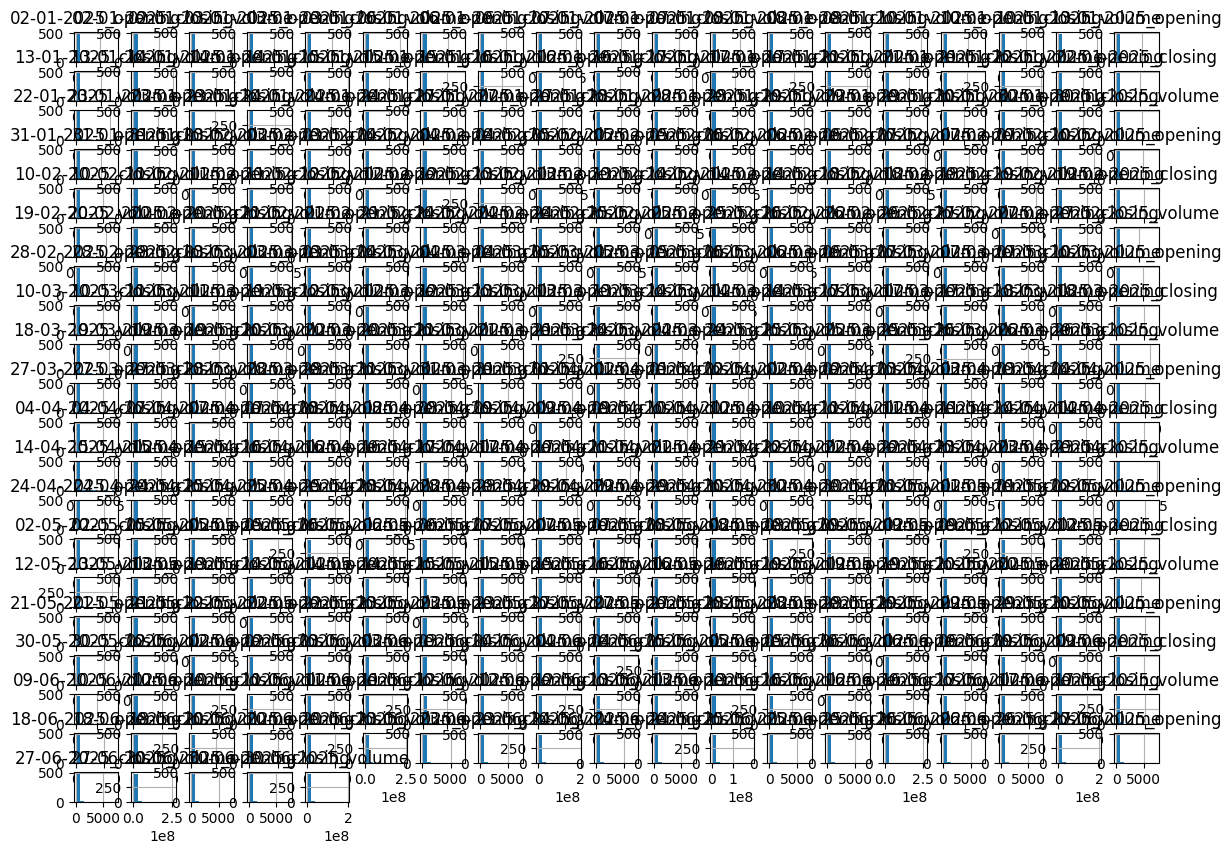

In [6]:
# --- Visualizations (Histograms) ---
df.hist(figsize=(14,10))
plt.show()

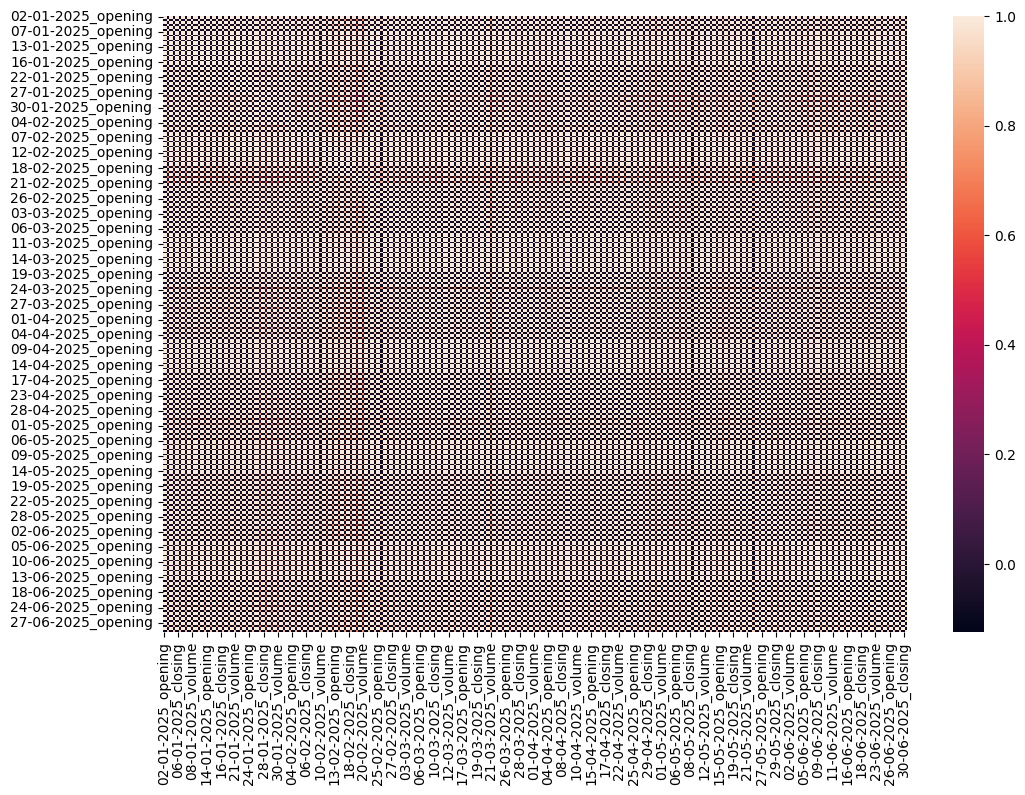

In [7]:
# --- Correlation Heatmap ---
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=False)
plt.show()

In [8]:
# --- Preprocessing ---
# Fill missing values
df = df.fillna(df.mean(numeric_only=True))

# Convert categorical columns using one-hot encoding
df = pd.get_dummies(df)
df.head()

,02-01-2025_opening,02-01-2025_closing,02-01-2025_volume,03-01-2025_opening,03-01-2025_closing,03-01-2025_volume,06-01-2025_opening,06-01-2025_closing,06-01-2025_volume,07-01-2025_opening,...,ticker_WY,ticker_WYNN,ticker_XEL,ticker_XOM,ticker_XYL,ticker_XYZ,ticker_YUM,ticker_ZBH,ticker_ZBRA,ticker_ZTS
0,136.000,138.310,198247166,140.010,144.470,229322478,148.590,149.430,265377359,153.030,...,False,False,False,False,False,False,False,False,False,False
1,425.530,418.580,16896469,421.080,423.350,16662943,428.000,427.850,20573648,429.000,...,False,False,False,False,False,False,False,False,False,False
2,248.657,243.582,55802016,243.093,243.093,40288361,244.042,244.731,45095097,242.713,...,False,False,False,False,False,False,False,False,False,False
3,222.030,220.220,33956579,222.505,224.190,27515606,226.780,227.610,31849831,227.900,...,False,False,False,False,False,False,False,False,False,False
4,589.720,599.240,12682269,604.760,604.630,11436784,611.825,630.200,14560754,631.700,...,False,False,False,False,False,False,False,False,False,False


In [12]:
# --- Splitting Data ---
X = df.drop('ticker_WY', axis=1)
y = df['ticker_WY']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
# --- Train Decision Trees (Gini, Entropy, Log-Loss) ---
criteria = ['gini', 'entropy', 'log_loss']
models = {}

for c in criteria:
    model = DecisionTreeClassifier(criterion=c, random_state=42)
    model.fit(X_train, y_train)
    models[c] = model
models

{'gini': DecisionTreeClassifier(random_state=42),
 'entropy': DecisionTreeClassifier(criterion='entropy', random_state=42),
 'log_loss': DecisionTreeClassifier(criterion='log_loss', random_state=42)}

In [14]:
# --- Model Evaluation ---
for c, model in models.items():
    preds = model.predict(X_test)
    print(f"\nCriterion: {c}")
    print("Accuracy:", accuracy_score(y_test, preds))
    print(confusion_matrix(y_test, preds))
    print(classification_report(y_test, preds))


Criterion: gini
Accuracy: 1.0
[[101]]
              precision    recall  f1-score   support

       False       1.00      1.00      1.00       101

    accuracy                           1.00       101
   macro avg       1.00      1.00      1.00       101
weighted avg       1.00      1.00      1.00       101


Criterion: entropy
Accuracy: 1.0
[[101]]
              precision    recall  f1-score   support

       False       1.00      1.00      1.00       101

    accuracy                           1.00       101
   macro avg       1.00      1.00      1.00       101
weighted avg       1.00      1.00      1.00       101


Criterion: log_loss
Accuracy: 1.0
[[101]]
              precision    recall  f1-score   support

       False       1.00      1.00      1.00       101

    accuracy                           1.00       101
   macro avg       1.00      1.00      1.00       101
weighted avg       1.00      1.00      1.00       101



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


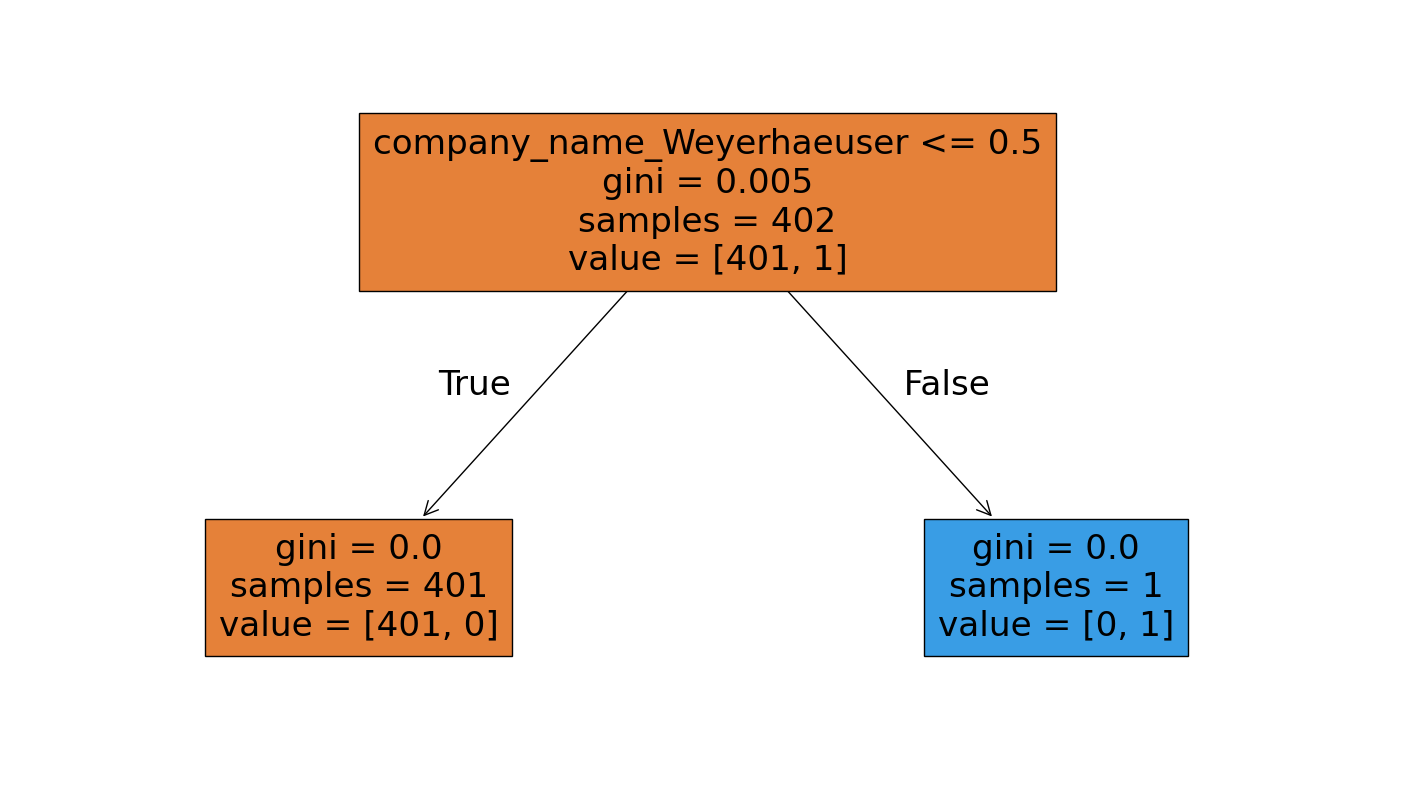

In [15]:
# --- Visualize the Tree (Gini Model) ---
plt.figure(figsize=(18,10))
plot_tree(models['gini'], filled=True, feature_names=X.columns)
plt.show()